<a href="https://colab.research.google.com/github/laramutair/Classification-model-learning/blob/main/Stroke_Classification_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classification Metrics (Core):


## Import and load the Dataset

In [45]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [46]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score,  confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

In [48]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv'
df = pd.read_csv(fpath)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


In [50]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1137.000000,1137.000000,1137.000000,1137.000000,1085.000000,1137.000000
mean,36750.933157,0.118734,0.068602,107.664002,29.198065,0.120493
std,21112.281253,0.323617,0.252887,47.618723,7.669615,0.325680
min,77.000000,0.000000,0.000000,55.270000,11.300000,0.000000
25%,17986.000000,0.000000,0.000000,77.600000,24.100000,0.000000
50%,37479.000000,0.000000,0.000000,91.820000,28.500000,0.000000
75%,55410.000000,0.000000,0.000000,113.850000,33.200000,0.000000
max,72918.000000,1.000000,1.000000,266.590000,64.400000,1.000000


In [51]:
df.describe(include='object')

,gender,age,ever_married,work_type,Residence_type,smoking_status
count,1137,1137,1137,1137,1137,1137
unique,3,84,2,5,2,4
top,Female,79,Yes,Private,Urban,never smoked
freq,642,26,769,672,587,416


## Clean Data

In [52]:
obj_col = df.select_dtypes(include='object').columns
obj_col

Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

In [53]:
for col in obj_col:
  print('-'*15)
  print(df[col].value_counts())

---------------
gender
Female    642
Male      494
Other       1
Name: count, dtype: int64
---------------
age
79     26
78     24
57     24
52     23
81     22
       ..
21      7
69      7
4       6
12      6
*82     1
Name: count, Length: 84, dtype: int64
---------------
ever_married
Yes    769
No     368
Name: count, dtype: int64
---------------
work_type
Private          672
Self-employed    174
children         147
Govt_job         142
Never_worked       2
Name: count, dtype: int64
---------------
Residence_type
Urban    587
Rural    550
Name: count, dtype: int64
---------------
smoking_status
never smoked       416
Unknown            352
formerly smoked    205
smokes             164
Name: count, dtype: int64


### In consistance data

In [54]:
df['age']= df['age'].replace('*82', '82')

In [55]:
df['age'] = df['age'].astype(int)

### ID as a index in DS

In [56]:
df['id'].is_unique

True

In [57]:
df = df.set_index('id')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


### Check Target Variable Distribution (Class Balance)

In [58]:
df['stroke'].value_counts(normalize=True)

,proportion
stroke,
0,0.879507
1,0.120493


### Imbalanced Dataset
   - 87% NO Stroke
   - 12% Stroke

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1137 entries, 1192 to 5731
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             1137 non-null   object 
 1   age                1137 non-null   int64  
 2   hypertension       1137 non-null   int64  
 3   heart_disease      1137 non-null   int64  
 4   ever_married       1137 non-null   object 
 5   work_type          1137 non-null   object 
 6   Residence_type     1137 non-null   object 
 7   avg_glucose_level  1137 non-null   float64
 8   bmi                1085 non-null   float64
 9   smoking_status     1137 non-null   object 
 10  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 106.6+ KB


## Train Test split

In [60]:
X = df.drop(columns='stroke')
y = df['stroke']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [62]:
X_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
id,,,,,,,,,,
23427,Female,81,0,0,Yes,Private,Rural,91.82,36.9,Unknown
68171,Male,61,0,0,Yes,Self-employed,Urban,116.78,39.8,formerly smoked
50536,Female,62,0,1,Yes,Govt_job,Urban,124.37,28.3,never smoked
35999,Female,52,0,0,Yes,Private,Urban,86.85,23.8,formerly smoked
47427,Male,49,0,0,Yes,Self-employed,Urban,70.73,27.3,formerly smoked


## preparing the numeric data

In [63]:
num_cols = ['age', 'bmi', 'avg_glucose_level']
X_train[num_cols].isna().sum()

,0
age,0
bmi,40
avg_glucose_level,0


In [64]:
# instantiate preprocessors
#impute messing value by median
impute_median = SimpleImputer(strategy='median')
# scaler
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
# Making a numeric tuple for ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)

## Categorical Preprocessing Pipeline


In [65]:
cat_cols = ['gender', 'hypertension','heart_disease', 'ever_married', 'work_type','Residence_type','smoking_status']

In [66]:
X_train[cat_cols].isna().sum()

,0
gender,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
smoking_status,0


In [67]:
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_tuple =('categorical', cat_encoder, cat_cols)

## Create the Column Transformer


In [68]:
# Create the Column Transformer
preprocessor = ColumnTransformer([num_tuple,cat_tuple],verbose_feature_names_out=False)

## Instantiate and Fit the Default Model (using a model pipeline)


In [69]:
# Instantiate a default decision tree
dec_tree_class = DecisionTreeClassifier(random_state=42)
dec_tree_pipe = make_pipeline(preprocessor, dec_tree_class)
# Fit the model on the training data
dec_tree_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'hypertension',
                                                   'heart_disease',
                                                   'ever_married', 'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



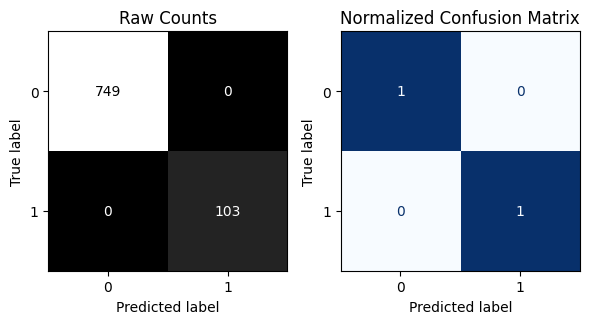


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       251
           1       0.38      0.32      0.35        34

    accuracy                           0.86       285
   macro avg       0.64      0.63      0.63       285
weighted avg       0.85      0.86      0.85       285



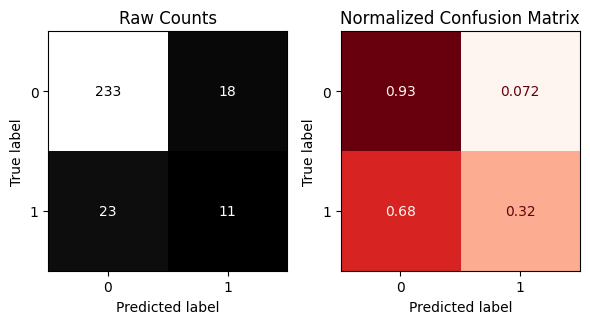

In [70]:
evaluate_classification(dec_tree_pipe, X_train, y_train,  X_test, y_test)

1- What was the overall accuracy of the model? (How would you describe the default model's performance considering the accuracy and class balance?)
  - Accuracy for training set: 100%
  - Accuracy for training set: 86%

  However, given that the dataset is highly imbalanced (88% No Stroke, 12% Stroke),
the 86% accuracy is **misleading**

2- Using this model, what percentage of the predictions would cause an unnecessary stroke alert for a patient who did not end up having a stroke? (A false positive)?
  - Precision 38%, meaning that when the model predicted a stroke,
it was correct only 38% of the time

3- Using this model, what percentage of the predictions would miss warning a patient who ended up having a stroke (False Negatives)
  - Recall 32%, meaning only 32% of real stroke patients
were correctly identified by the model.

4- Considering that this dataset is used to identify strokes, which metric do you think would be important to optimize? Why?
   - I think a Recall is more important than precision, because a missed stroke can lead to  death, while a false alarm only results in further testing.


# Assignment LogReg, Random Forest, or KNN (Core)

## 1) Logistic Regression

### a) Start by creating and evaluating a default logistic regression model using appropriate metrics and a confusion matrix.

In [72]:
defalt = LogisticRegression(random_state=42)
defalt_pipe = make_pipeline(preprocessor, defalt)
# Fit the model on the training data
defalt_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'hypertension',
                                                   'heart_disease',
                                                   'ever_married', 'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       749
           1       0.52      0.16      0.24       103

    accuracy                           0.88       852
   macro avg       0.71      0.57      0.59       852
weighted avg       0.85      0.88      0.85       852



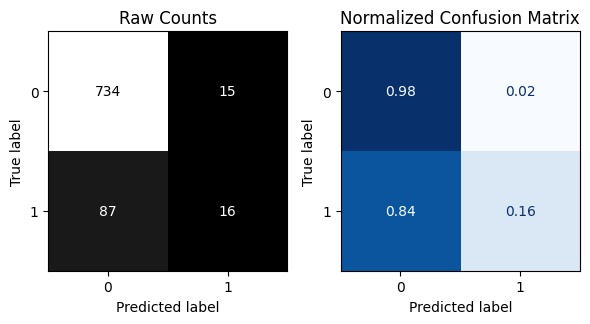


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.17      0.03      0.05        34

    accuracy                           0.87       285
   macro avg       0.52      0.50      0.49       285
weighted avg       0.80      0.87      0.82       285



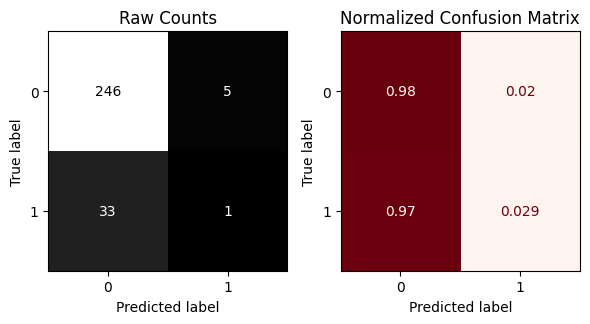

In [73]:
evaluate_classification(defalt_pipe, X_train, y_train,  X_test, y_test)

In [74]:
defalt = LogisticRegression(random_state=42, max_iter=1000)
defalt_pipe = make_pipeline(preprocessor, defalt)
# Fit the model on the training data
defalt_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'avg_glucose_level']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'hypertension',
                                                   'heart_disease',
                                                   'ever_married', 'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       749
           1       0.52      0.16      0.24       103

    accuracy                           0.88       852
   macro avg       0.71      0.57      0.59       852
weighted avg       0.85      0.88      0.85       852



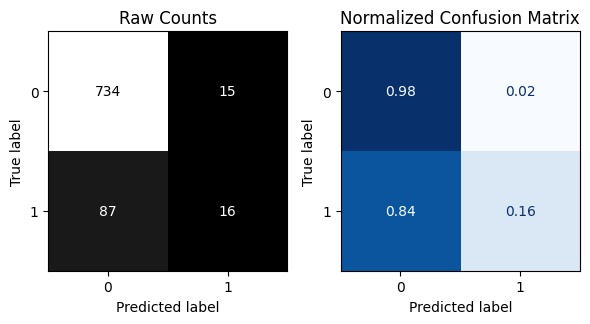


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.17      0.03      0.05        34

    accuracy                           0.87       285
   macro avg       0.52      0.50      0.49       285
weighted avg       0.80      0.87      0.82       285



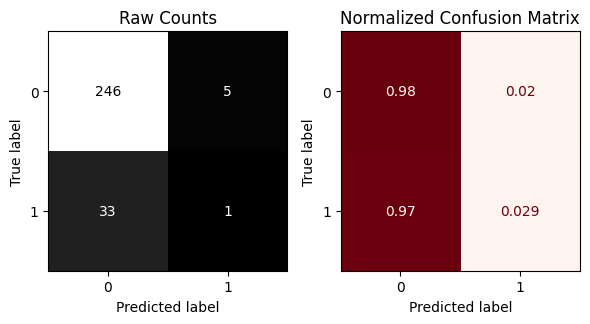

In [75]:
evaluate_classification(defalt_pipe, X_train, y_train,  X_test, y_test)